#  GC PSAR — Optimización, Sizing y Validación Out-of-Sample
## Notebook B.03 del Hands-On: Masterclass de Diseño de Estrategias Cuantitativas

---

**Objetivo:** Superficie de optimización, comparar sizing, y ejecutar la validación IS/OOS para el PSAR en Oro.

| Slide | Concepto |
|:---:|---|
| 10 | Meseta vs Pico |
| 11 | Sizing: Fixed vs Reinversión vs Apalancamiento |
| 12 | Validación IS vs OOS |
| 13 | Ficha final |

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import pandas_ta_classic as ta
import vectorbt as vbt
import warnings
warnings.filterwarnings('ignore')

import sys; sys.path.insert(0, '.')
from nb_style import *

---
## 1. Carga y Preparación

In [8]:
section_header('CARGA DE DATOS @GC', '')

df_5m = pd.read_csv('../@GC_5m.csv', parse_dates=['TimeStamp'])
df_5m.set_index('TimeStamp', inplace=True)
df_1h = df_5m.resample('1h', label='left').agg({
    'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last',
    'TotalVolume': 'sum'
}).dropna(subset=['Open']).copy()

df_1h['Year'] = df_1h.index.year
print(f'Barras 1h: {len(df_1h):,}')
print(f'Años: {df_1h["Year"].min()} – {df_1h["Year"].max()}')


══════════════════════════════════════════════════════════════════════
  CARGA DE DATOS @GC
══════════════════════════════════════════════════════════════════════

Barras 1h: 138,836
Años: 2002 – 2026


---
## 2. Superficie de Optimización (Slide 10)

Barremos AF × MaxAF y visualizamos el Sharpe para identificar mesetas.


══════════════════════════════════════════════════════════════════════
 🔎 BARRIDO DE OPTIMIZACIÓN
══════════════════════════════════════════════════════════════════════

IS: 91,985 barras (2002-2018)
OOS: 46,851 barras (2019-2026)
  AF=0.002, MaxAF=0.05: Sharpe=0.360, N=590
  AF=0.002, MaxAF=0.1: Sharpe=0.362, N=590
  AF=0.002, MaxAF=0.15: Sharpe=0.362, N=590
  AF=0.002, MaxAF=0.2: Sharpe=0.362, N=590
  AF=0.002, MaxAF=0.3: Sharpe=0.362, N=590
  AF=0.005, MaxAF=0.05: Sharpe=0.053, N=882
  AF=0.005, MaxAF=0.1: Sharpe=0.050, N=898
  AF=0.005, MaxAF=0.15: Sharpe=0.047, N=898
  AF=0.005, MaxAF=0.2: Sharpe=0.047, N=898
  AF=0.005, MaxAF=0.3: Sharpe=0.047, N=898
  AF=0.008, MaxAF=0.05: Sharpe=-0.470, N=945
  AF=0.008, MaxAF=0.1: Sharpe=-0.125, N=953
  AF=0.008, MaxAF=0.15: Sharpe=0.056, N=953
  AF=0.008, MaxAF=0.2: Sharpe=0.066, N=953
  AF=0.008, MaxAF=0.3: Sharpe=0.066, N=953
  AF=0.01, MaxAF=0.05: Sharpe=-0.492, N=922
  AF=0.01, MaxAF=0.1: Sharpe=-0.179, N=915
  AF=0.01, MaxAF=0.15: Sharp

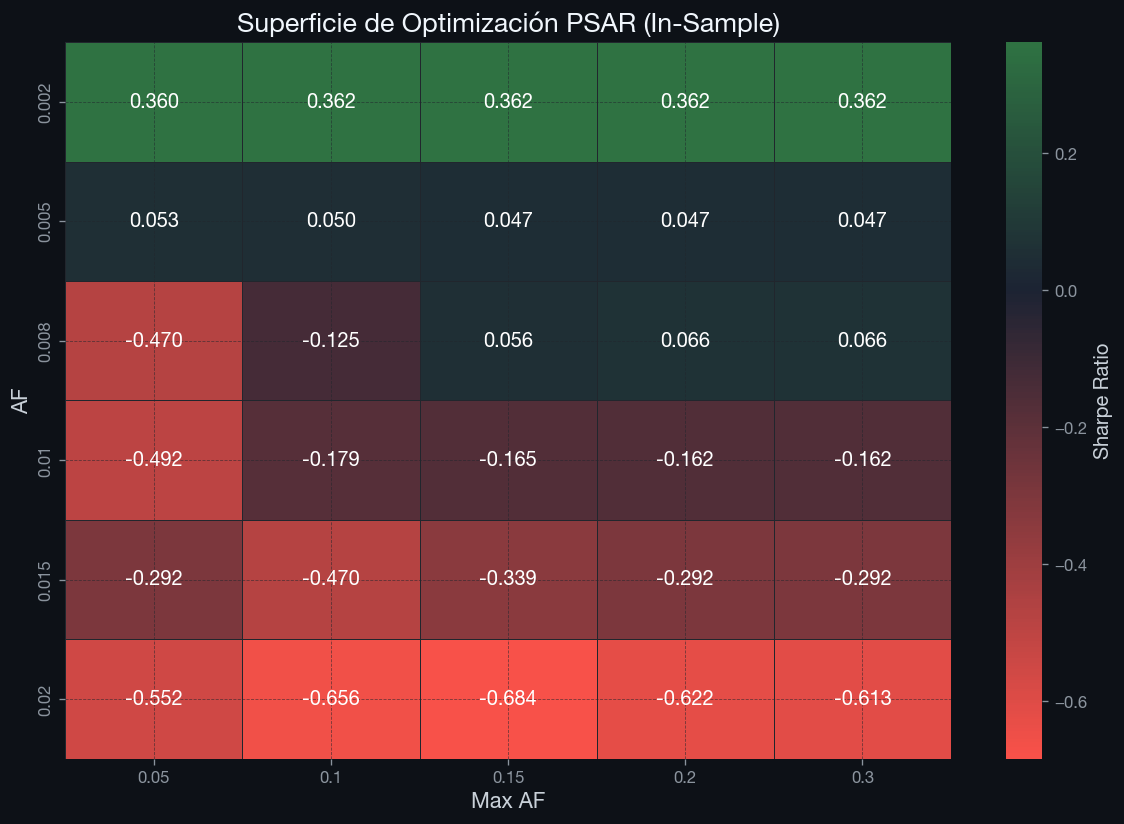

In [9]:
# ═══ BARRIDO AF × MAX_AF CON SPLIT IS/OOS ═══
section_header('BARRIDO DE OPTIMIZACIÓN', '🔎')

IS_CUTOFF = 2019
df_IS = df_1h[df_1h['Year'] < IS_CUTOFF].copy()
df_OOS = df_1h[df_1h['Year'] >= IS_CUTOFF].copy()
print(f'IS: {len(df_IS):,} barras ({df_IS["Year"].min()}-{df_IS["Year"].max()})')
print(f'OOS: {len(df_OOS):,} barras ({df_OOS["Year"].min()}-{df_OOS["Year"].max()})')

af_range = [0.002, 0.005, 0.008, 0.01, 0.015, 0.02]
maxaf_range = [0.05, 0.10, 0.15, 0.20, 0.30]
THRESH = 24

def eval_psar(df, af, maxaf, thresh=24):
    psar = df.ta.psar(af=af, max_af=maxaf)
    col_l = f'PSARl_{af}_{maxaf}'
    col_s = f'PSARs_{af}_{maxaf}'
    if col_l not in psar.columns: return None
    
    bull = psar[col_l].notnull()
    s = 0
    streaks = []
    for v in bull.values:
        s = s + 1 if v else 0
        streaks.append(s)
    
    entry = pd.Series(np.array(streaks) == thresh, index=df.index)
    exit_sig = psar[col_s].notnull() & (~psar[col_s].shift(1).notnull().fillna(False))
    
    pf = vbt.Portfolio.from_signals(close=df['Close'], entries=entry, exits=exit_sig,
                                     init_cash=100000, fees=0.0001, freq='1h')
    n = pf.trades.count()
    if n < 5: return None
    sh = pf.sharpe_ratio()
    return {
        'Trades': n, 'Sharpe': sh if not np.isnan(sh) else 0,
        'Return': pf.total_return() * 100,
        'WR': pf.trades.win_rate() * 100,
        'PF': pf.trades.profit_factor() if not np.isnan(pf.trades.profit_factor()) else 0,
        'MaxDD': pf.max_drawdown() * 100,
        'portfolio': pf
    }

# Optimizar solo en IS
results_is = {}
best_sharpe = -np.inf
best_params = (0.005, 0.15)

for af in af_range:
    for maxaf in maxaf_range:
        res = eval_psar(df_IS, af, maxaf, THRESH)
        if res:
            results_is[(af, maxaf)] = res
            if res['Sharpe'] > best_sharpe:
                best_sharpe = res['Sharpe']
                best_params = (af, maxaf)
            print(f'  AF={af}, MaxAF={maxaf}: Sharpe={res["Sharpe"]:.3f}, N={res["Trades"]}')

print(f'\n Mejor IS: AF={best_params[0]}, MaxAF={best_params[1]} (Sharpe={best_sharpe:.3f})')

# Heatmap
sharpe_grid = np.full((len(af_range), len(maxaf_range)), np.nan)
for i, af in enumerate(af_range):
    for j, maxaf in enumerate(maxaf_range):
        if (af, maxaf) in results_is:
            sharpe_grid[i, j] = results_is[(af, maxaf)]['Sharpe']

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(sharpe_grid, annot=True, fmt='.3f', cmap=CMAP_DIVERGENT, center=0, ax=ax,
            xticklabels=[str(v) for v in maxaf_range],
            yticklabels=[str(v) for v in af_range],
            linewidths=0.5, linecolor=COLORS['grid'],
            annot_kws={'fontsize': 12, 'fontweight': 'bold'},
            cbar_kws={'label': 'Sharpe Ratio'})
ax.set_title('Superficie de Optimización PSAR (In-Sample)', fontsize=16, fontweight='bold',
             color=COLORS['text_bright'])
ax.set_xlabel('Max AF', fontsize=13)
ax.set_ylabel('AF', fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. Sizing: Fixed vs Reinversión vs Apalancamiento (Slide 11)


══════════════════════════════════════════════════════════════════════
 💰 COMPARACIÓN DE SIZING
══════════════════════════════════════════════════════════════════════

Trades: 915
PnL total: $69,667
Retorno medio por trade: 0.08%


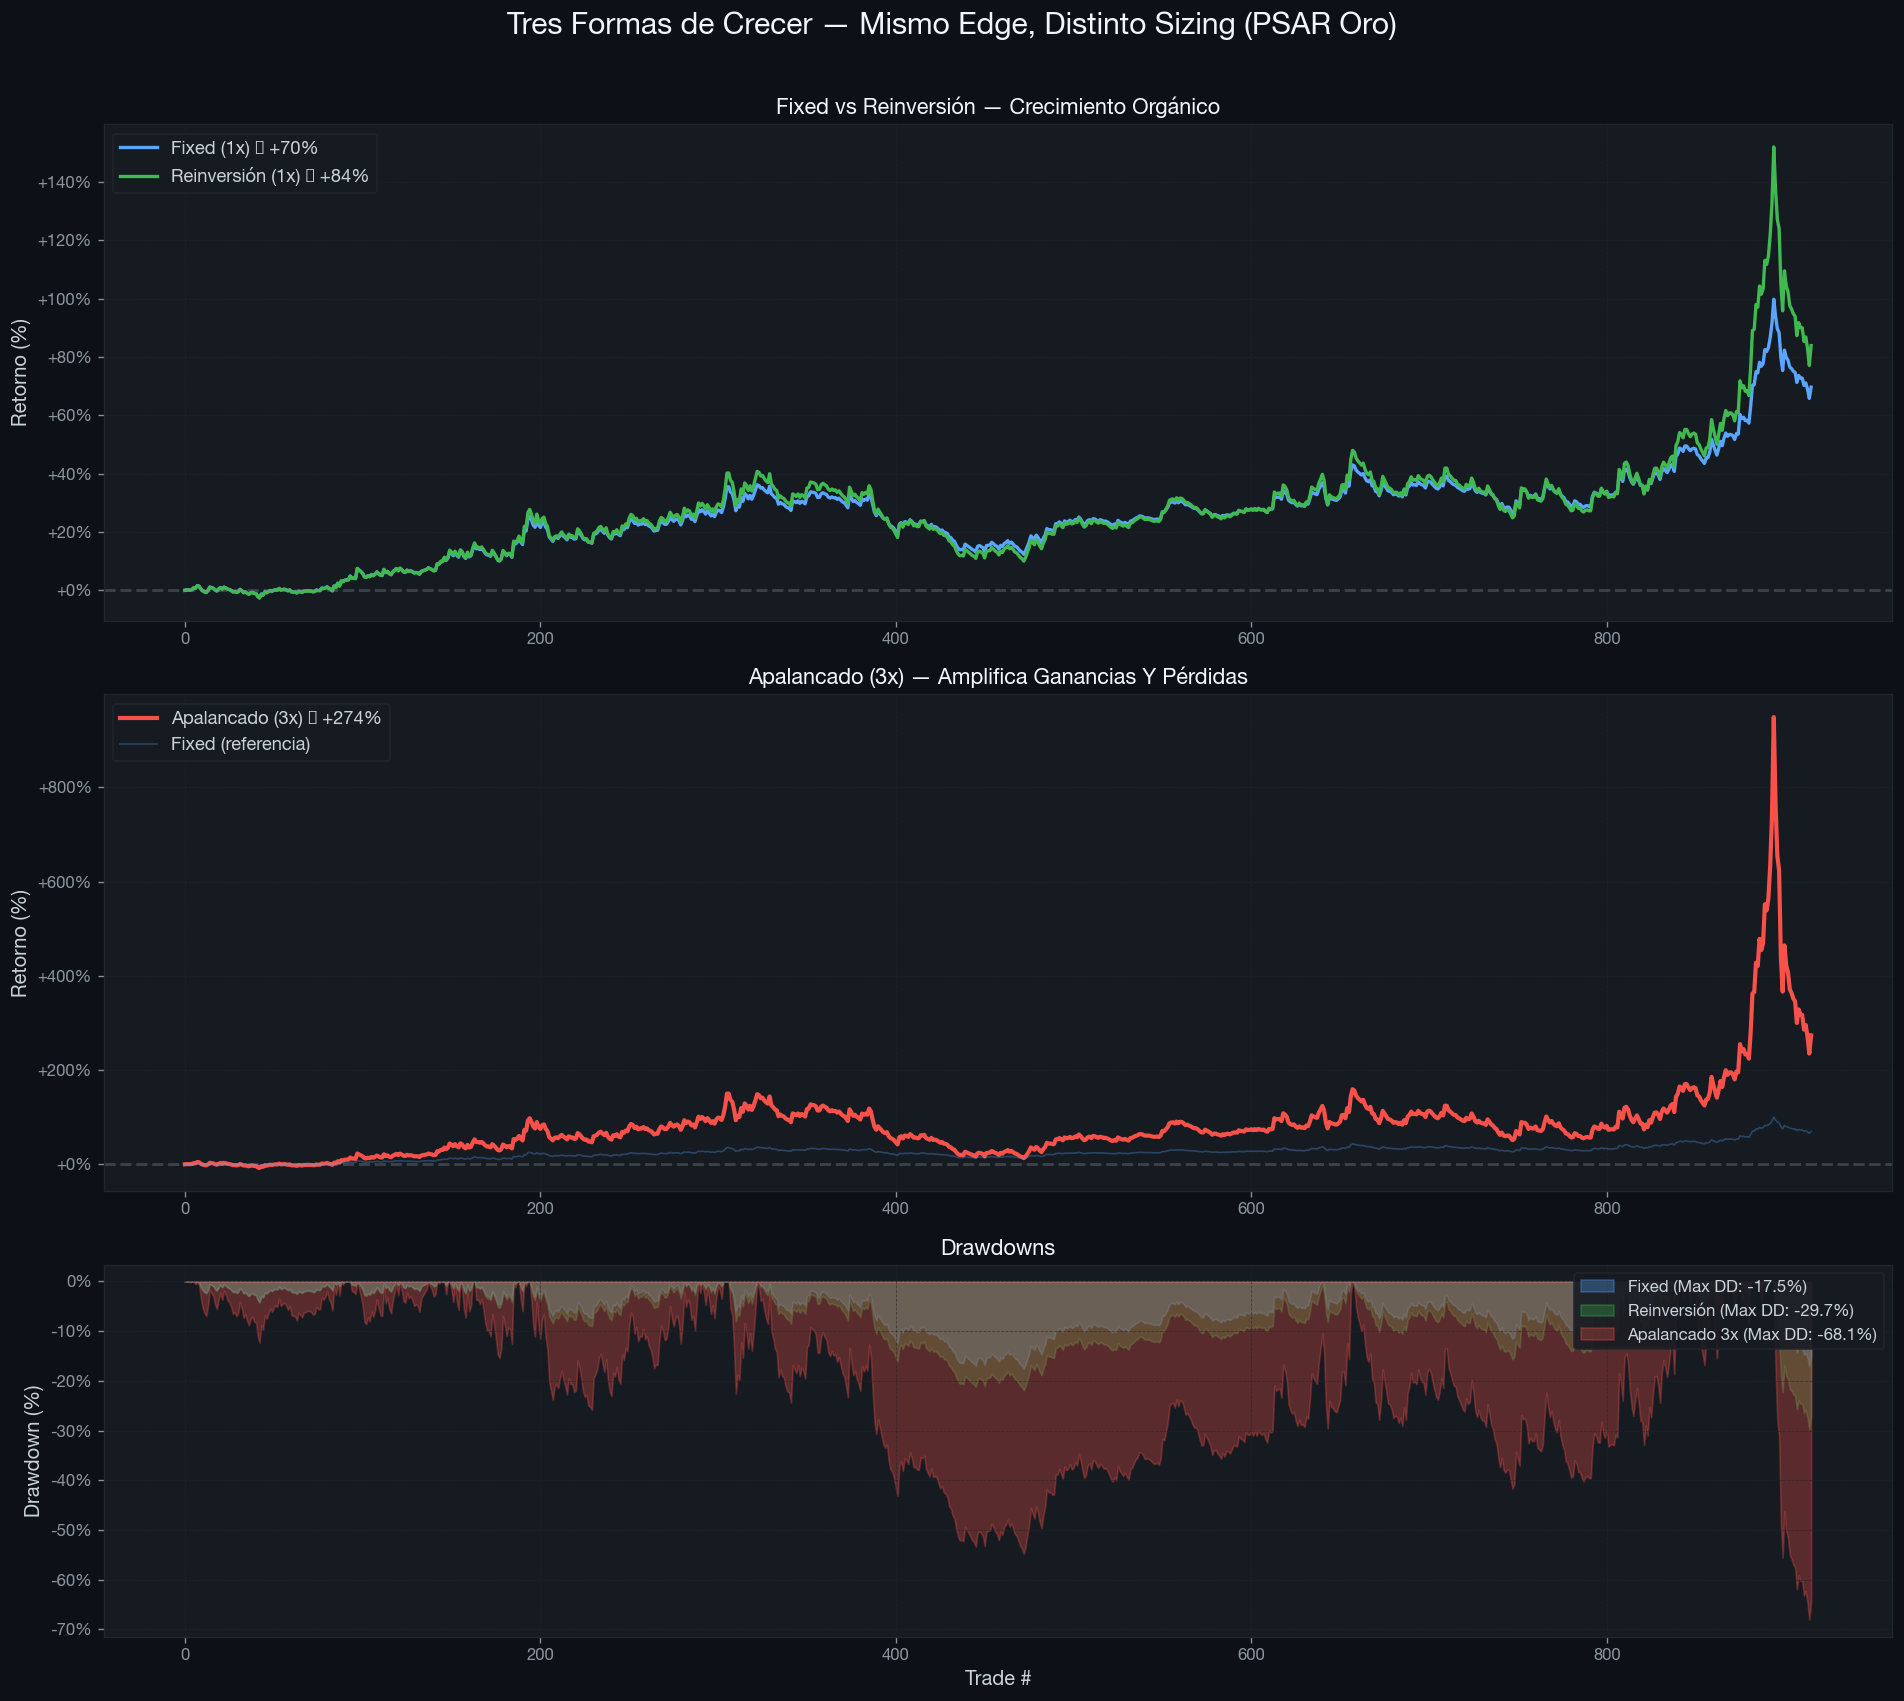


══════════════════════════════════════════════════════════════════════
  LECCIÓN DE SIZING
══════════════════════════════════════════════════════════════════════

Fixed (1x):              +70%  ($     169,667)
Reinversión (1x):        +84%  ($     183,930)
Apalancado (3x):        +274%  ($     373,535)

El apalancamiento amplifica TANTO las ganancias como las pérdidas.
La reinversión compone los retornos de forma orgánica.


In [10]:
# ═══ SIZING COMPARISON ═══
section_header('COMPARACIÓN DE SIZING', '💰')

af_best, maxaf_best = best_params
res_full = eval_psar(df_1h, af_best, maxaf_best, THRESH)

if res_full:
    pf_full = res_full['portfolio']
    
    # Extraer PnL por trade como fracción del capital
    trade_records = pf_full.trades.records_readable
    trade_pnl = trade_records['PnL'].values
    trade_rets_frac = trade_pnl / INIT_CASH
    
    print(f'Trades: {len(trade_rets_frac)}')
    print(f'PnL total: ${trade_pnl.sum():,.0f}')
    print(f'Retorno medio por trade: {trade_rets_frac.mean()*100:.2f}%')
    
    # ─── Simular 3 métodos de sizing ───
    init = INIT_CASH
    
    eq_fixed = [init]
    for r in trade_rets_frac:
        eq_fixed.append(eq_fixed[-1] + init * r)
    
    eq_reinv = [init]
    for r in trade_rets_frac:
        eq_reinv.append(max(eq_reinv[-1] + eq_reinv[-1] * r, 1))
    
    eq_kelly = [init]
    for r in trade_rets_frac:
        eq_kelly.append(max(eq_kelly[-1] + eq_kelly[-1] * r * 3, 1))
    
    # Convertir a retorno porcentual
    ret_fixed = [(v / init - 1) * 100 for v in eq_fixed]
    ret_reinv = [(v / init - 1) * 100 for v in eq_reinv]
    ret_kelly = [(v / init - 1) * 100 for v in eq_kelly]
    
    # ═══ GRÁFICO: 3 paneles separados + drawdowns ═══
    fig, axes = plt.subplots(3, 1, figsize=(16, 14), gridspec_kw={'height_ratios': [2, 2, 1.5]})
    fig.suptitle('Tres Formas de Crecer — Mismo Edge, Distinto Sizing (PSAR Oro)',
                 fontsize=18, fontweight='bold', color=COLORS['text_bright'], y=1.01)
    
    # ─── Panel 1: Fixed + Reinversión (escala similar) ───
    ax = axes[0]
    ax.plot(ret_fixed, color=COLORS['blue'], lw=2, label=f'Fixed (1x) → {ret_fixed[-1]:+,.0f}%')
    ax.plot(ret_reinv, color=COLORS['green'], lw=2, label=f'Reinversión (1x) → {ret_reinv[-1]:+,.0f}%')
    ax.axhline(0, color=COLORS['text_dim'], linestyle='--', alpha=0.3)
    ax.set_ylabel('Retorno (%)')
    ax.set_title('Fixed vs Reinversión — Crecimiento Orgánico', color=COLORS['text_bright'], fontsize=13)
    ax.legend(fontsize=11, loc='upper left')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%+.0f%%'))
    
    # ─── Panel 2: Apalancado (escala propia) ───
    ax = axes[1]
    ax.plot(ret_kelly, color=COLORS['red'], lw=2.5, label=f'Apalancado (3x) → {ret_kelly[-1]:+,.0f}%')
    ax.plot(ret_fixed, color=COLORS['blue'], lw=1, alpha=0.3, label='Fixed (referencia)')
    ax.axhline(0, color=COLORS['text_dim'], linestyle='--', alpha=0.3)
    ax.set_ylabel('Retorno (%)')
    ax.set_title('Apalancado (3x) — Amplifica Ganancias Y Pérdidas', color=COLORS['text_bright'], fontsize=13)
    ax.legend(fontsize=11, loc='upper left')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%+.0f%%'))
    
    # ─── Panel 3: Drawdowns ───
    ax = axes[2]
    for eq, color, label in [(eq_fixed, COLORS['blue'], 'Fixed'),
                              (eq_reinv, COLORS['green'], 'Reinversión'),
                              (eq_kelly, COLORS['red'], 'Apalancado 3x')]:
        eq_arr = np.array(eq)
        peak = np.maximum.accumulate(eq_arr)
        dd = (eq_arr - peak) / peak * 100
        ax.fill_between(range(len(dd)), dd, 0, color=color, alpha=0.3,
                        label=f'{label} (Max DD: {dd.min():.1f}%)')
    ax.set_ylabel('Drawdown (%)')
    ax.set_xlabel('Trade #')
    ax.set_title('Drawdowns', color=COLORS['text_bright'], fontsize=13)
    ax.legend(fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    
    plt.tight_layout()
    plt.show()
    
    section_header('LECCIÓN DE SIZING', '')
    print(f'Fixed (1x):       {ret_fixed[-1]:>+10,.0f}%  (${eq_fixed[-1]:>12,.0f})')
    print(f'Reinversión (1x): {ret_reinv[-1]:>+10,.0f}%  (${eq_reinv[-1]:>12,.0f})')
    print(f'Apalancado (3x):  {ret_kelly[-1]:>+10,.0f}%  (${eq_kelly[-1]:>12,.0f})')
    print()
    print('El apalancamiento amplifica TANTO las ganancias como las pérdidas.')
    print('La reinversión compone los retornos de forma orgánica.')
else:
    print(' No se pudo evaluar la estrategia completa.')

---
## 4.  Validación In-Sample vs Out-of-Sample (Slide 12)


══════════════════════════════════════════════════════════════════════
  VALIDACIÓN IN-SAMPLE vs OUT-OF-SAMPLE
══════════════════════════════════════════════════════════════════════


Métrica.......................    In-Sample   Out-of-Sample  Degradación    Señal
────────────────────────────────────────────────────────────────────────────────
Sharpe Ratio..................         0.36            0.61       69.1%        💀
Win Rate (%)..................        41.36           39.32        4.9%        
Profit Factor.................         1.13            1.24       10.3%        
Max Drawdown (%)..............       -18.24          -22.64       24.1%        
Retorno Total (%).............        25.93           34.36       32.5%        


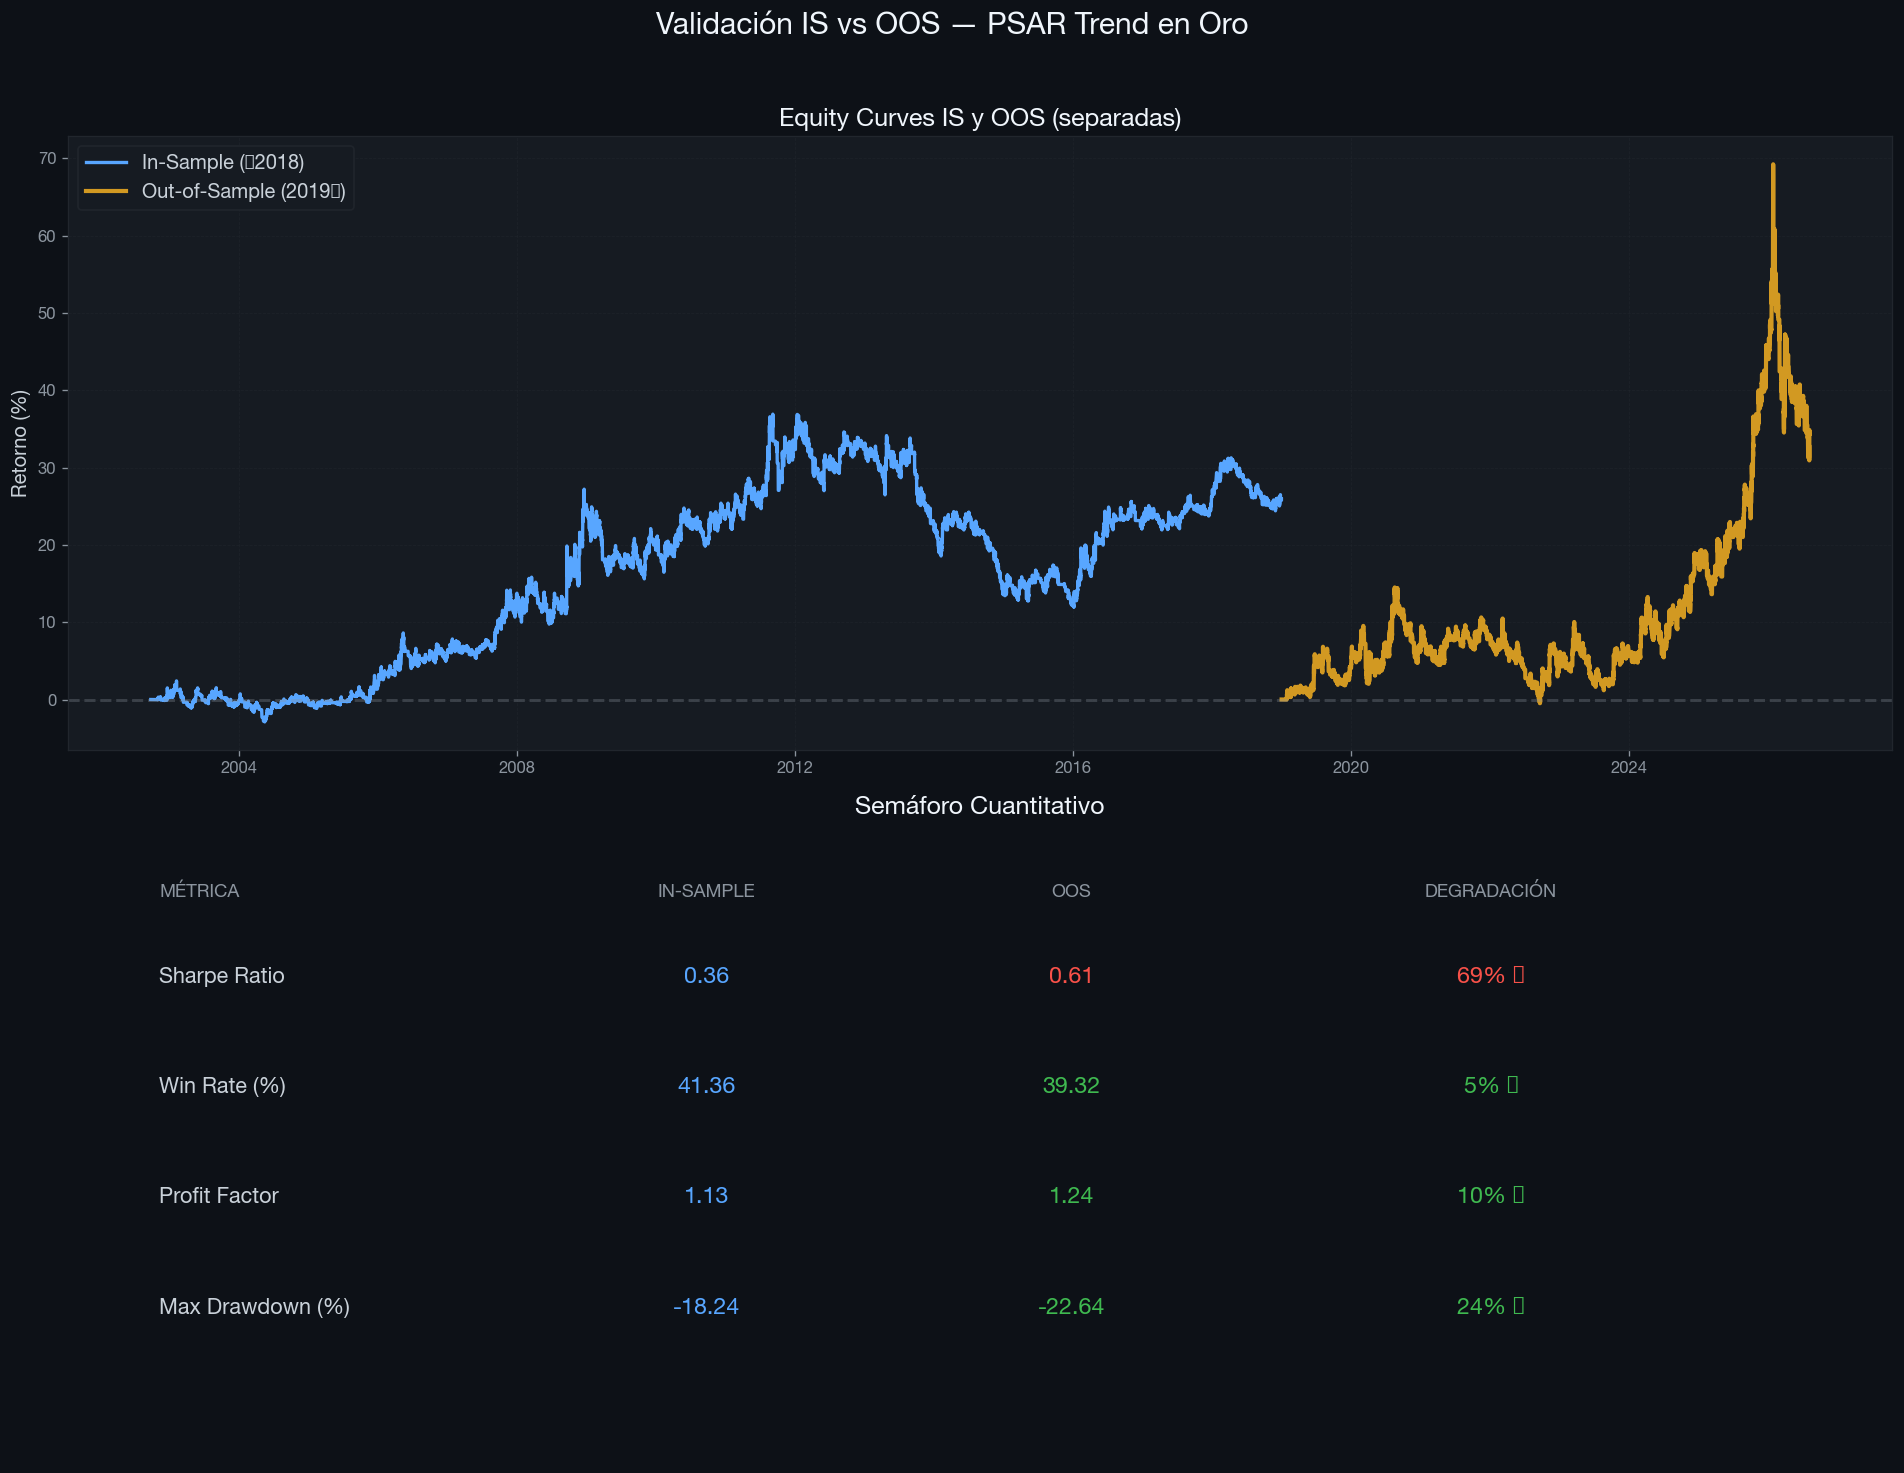

In [11]:
# ═══ VALIDACIÓN IS vs OOS ═══
section_header('VALIDACIÓN IN-SAMPLE vs OUT-OF-SAMPLE', '')

af_best, maxaf_best = best_params
m_IS = eval_psar(df_IS, af_best, maxaf_best, THRESH)
m_OOS = eval_psar(df_OOS, af_best, maxaf_best, THRESH)

if m_IS and m_OOS:
    # Tabla de degradación
    print(f'\n{"Métrica":.<30s} {"In-Sample":>12s} {"Out-of-Sample":>15s} {"Degradación":>12s} {"Señal":>8s}')
    print('─' * 80)
    
    comparisons = [
        ('Sharpe Ratio', m_IS['Sharpe'], m_OOS['Sharpe'], 30),
        ('Win Rate (%)', m_IS['WR'], m_OOS['WR'], 15),
        ('Profit Factor', m_IS['PF'], m_OOS['PF'], 25),
        ('Max Drawdown (%)', m_IS['MaxDD'], m_OOS['MaxDD'], 50),
        ('Retorno Total (%)', m_IS['Return'], m_OOS['Return'], 50),
    ]
    
    for name, is_v, oos_v, thresh_v in comparisons:
        deg = abs(is_v - oos_v) / abs(is_v) * 100 if is_v != 0 else 0
        signal = '' if deg <= thresh_v else ('' if deg <= thresh_v*2 else '💀')
        print(f'{name:.<30s} {is_v:>12.2f} {oos_v:>15.2f} {deg:>10.1f}% {signal:>8s}')
    
    # Gráfico
    fig, axes = plt.subplots(2, 1, figsize=(16, 12))
    fig.suptitle('Validación IS vs OOS — PSAR Trend en Oro', 
                 fontsize=18, fontweight='bold', color=COLORS['text_bright'], y=1.02)
    
    # Panel A: Equity curves
    ax = axes[0]
    eq_is = (m_IS['portfolio'].value() / 100000 - 1) * 100
    eq_oos = (m_OOS['portfolio'].value() / 100000 - 1) * 100
    
    ax.plot(eq_is.index, eq_is.values, color=COLORS['blue'], lw=2, label=f'In-Sample (→{IS_CUTOFF-1})')
    ax.plot(eq_oos.index, eq_oos.values, color=COLORS['orange'], lw=2.5, label=f'Out-of-Sample ({IS_CUTOFF}→)')
    ax.axhline(0, color=COLORS['text_dim'], linestyle='--', alpha=0.3)
    ax.set_ylabel('Retorno (%)')
    ax.set_title('Equity Curves IS y OOS (separadas)', color=COLORS['text_bright'])
    ax.legend(fontsize=12)
    
    # Panel B: Semáforo
    ax = axes[1]
    ax.axis('off')
    metrics_vis = [
        ('Sharpe Ratio', m_IS['Sharpe'], m_OOS['Sharpe'], 30),
        ('Win Rate (%)', m_IS['WR'], m_OOS['WR'], 15),
        ('Profit Factor', m_IS['PF'], m_OOS['PF'], 25),
        ('Max Drawdown (%)', m_IS['MaxDD'], m_OOS['MaxDD'], 50),
    ]
    
    for x, txt in [(0.05, 'MÉTRICA'), (0.35, 'IN-SAMPLE'), (0.55, 'OOS'), (0.78, 'DEGRADACIÓN')]:
        ax.text(x, 0.92, txt, fontsize=11, color=COLORS['text_dim'], fontweight='bold',
                transform=ax.transAxes, ha='left' if x < 0.1 else 'center')
    
    for i, (name, is_v, oos_v, tv) in enumerate(metrics_vis):
        y = 0.78 - i * 0.18
        deg = abs(is_v - oos_v) / abs(is_v) * 100 if is_v != 0 else 0
        color = COLORS['green'] if deg <= tv else (COLORS['orange'] if deg <= tv*2 else COLORS['red'])
        emoji = '' if deg <= tv else ('' if deg <= tv*2 else '💀')
        
        ax.text(0.05, y, name, fontsize=13, color=COLORS['text'], fontweight='bold', transform=ax.transAxes)
        ax.text(0.35, y, f'{is_v:.2f}', fontsize=14, color=COLORS['blue'], transform=ax.transAxes, ha='center')
        ax.text(0.55, y, f'{oos_v:.2f}', fontsize=14, color=color, fontweight='bold', transform=ax.transAxes, ha='center')
        ax.text(0.78, y, f'{deg:.0f}% {emoji}', fontsize=14, color=color, fontweight='bold', transform=ax.transAxes, ha='center')
    
    ax.set_title('Semáforo Cuantitativo', fontsize=15, fontweight='bold', color=COLORS['text_bright'], pad=20)
    plt.tight_layout()
    plt.show()
else:
    print(' Datos insuficientes para IS o OOS.')

---
## 5. Ficha Final de Estrategia — GC PSAR Trend

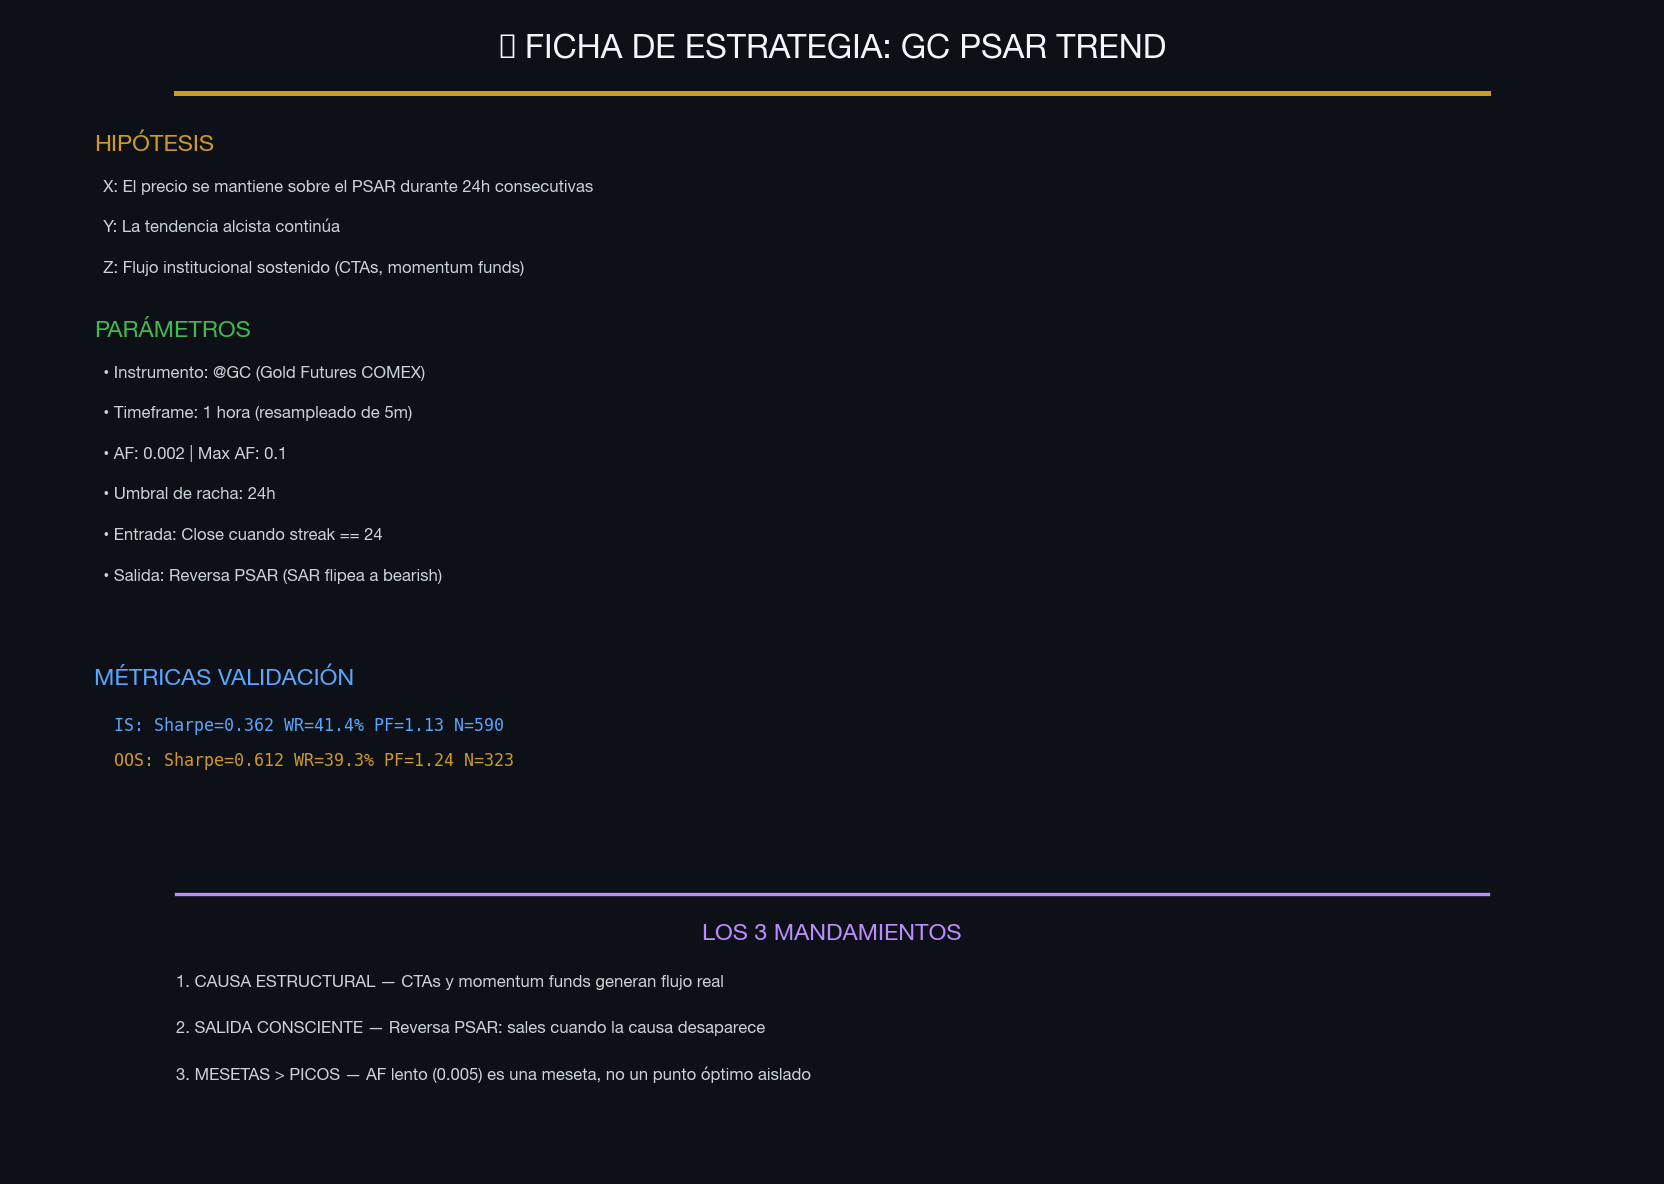


══════════════════════════════════════════════════════════════════════
 🏁 MASTERCLASS HANDS-ON COMPLETO
══════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
  SERIE A — NQ Gap Fade:     3 Notebooks 
  SERIE B — GC PSAR Trend:   3 Notebooks 
════════════════════════════════════════════════════════════

Cada concepto del masterclass fue demostrado
con datos reales de +20 años de futuros.


In [12]:
# ═══ FICHA FINAL ═══
fig, ax = plt.subplots(figsize=(14, 10))
ax.axis('off')
fig.patch.set_facecolor(COLORS['bg'])

ax.text(0.5, 0.96, ' FICHA DE ESTRATEGIA: GC PSAR TREND', fontsize=20, fontweight='bold',
        color=COLORS['text_bright'], ha='center', transform=ax.transAxes)
ax.axhline(0.93, color=COLORS['orange'], lw=3, xmin=0.1, xmax=0.9)

y = 0.88
ax.text(0.05, y, 'HIPÓTESIS', fontsize=14, fontweight='bold', color=COLORS['orange'], transform=ax.transAxes)
hipotesis = [
    'X: El precio se mantiene sobre el PSAR durante 24h consecutivas',
    'Y: La tendencia alcista continúa',
    'Z: Flujo institucional sostenido (CTAs, momentum funds)',
]
for j, h in enumerate(hipotesis):
    ax.text(0.05, y - 0.035*(j+1), f'  {h}', fontsize=10, color=COLORS['text'], transform=ax.transAxes)

y = 0.72
ax.text(0.05, y, 'PARÁMETROS', fontsize=14, fontweight='bold', color=COLORS['green'], transform=ax.transAxes)
params = [
    f'Instrumento: @GC (Gold Futures COMEX)',
    f'Timeframe: 1 hora (resampleado de 5m)',
    f'AF: {best_params[0]} | Max AF: {best_params[1]}',
    f'Umbral de racha: {THRESH}h',
    f'Entrada: Close cuando streak == {THRESH}',
    f'Salida: Reversa PSAR (SAR flipea a bearish)',
]
for j, p in enumerate(params):
    ax.text(0.05, y - 0.035*(j+1), f'  • {p}', fontsize=10, color=COLORS['text'], transform=ax.transAxes)

y = 0.42
ax.text(0.05, y, 'MÉTRICAS VALIDACIÓN', fontsize=14, fontweight='bold', color=COLORS['blue'], transform=ax.transAxes)
if m_IS and m_OOS:
    ax.text(0.05, y-0.04, f'  IS: Sharpe={m_IS["Sharpe"]:.3f} WR={m_IS["WR"]:.1f}% PF={m_IS["PF"]:.2f} N={m_IS["Trades"]}',
            fontsize=10, color=COLORS['blue'], transform=ax.transAxes, family='monospace')
    ax.text(0.05, y-0.07, f'  OOS: Sharpe={m_OOS["Sharpe"]:.3f} WR={m_OOS["WR"]:.1f}% PF={m_OOS["PF"]:.2f} N={m_OOS["Trades"]}',
            fontsize=10, color=COLORS['orange'], transform=ax.transAxes, family='monospace')

# Mandamientos
y = 0.20
ax.axhline(y + 0.04, color=COLORS['purple'], lw=2, xmin=0.1, xmax=0.9)
ax.text(0.5, y, 'LOS 3 MANDAMIENTOS', fontsize=14, fontweight='bold',
        color=COLORS['purple'], ha='center', transform=ax.transAxes)
mandamientos = [
    '1. CAUSA ESTRUCTURAL — CTAs y momentum funds generan flujo real',
    '2. SALIDA CONSCIENTE — Reversa PSAR: sales cuando la causa desaparece',
    '3. MESETAS > PICOS — AF lento (0.005) es una meseta, no un punto óptimo aislado',
]
for j, m in enumerate(mandamientos):
    ax.text(0.10, y - 0.04*(j+1), m, fontsize=10, color=COLORS['text'], transform=ax.transAxes)

plt.tight_layout()
plt.show()

section_header('MASTERCLASS HANDS-ON COMPLETO', '🏁')
print('═' * 60)
print('  SERIE A — NQ Gap Fade:     3 Notebooks ')
print('  SERIE B — GC PSAR Trend:   3 Notebooks ')
print('═' * 60)
print()
print('Cada concepto del masterclass fue demostrado')
print('con datos reales de +20 años de futuros.')